# House Prices - Prediction Project

Projeto de Machine Learning para predição de preços de imóveis utilizando o dataset do Kaggle (*House Prices - Advanced Regression Techniques*).

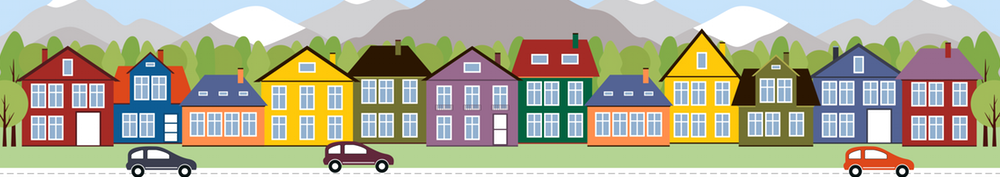

## 📊 Origem dos Dados

Os dados utilizados neste projeto não estão versionados no repositório por questões de boas práticas e tamanho de ficheiros. Para obtê-los:

1. Acesse a [competição do Kaggle](https://www.kaggle.com/c/house-prices-advanced-regression-techniques).
2. Faça o download dos ficheiros (`train.csv`, `test.csv`, `data_description.txt`, `sample_submission.csv`).
3. Coloque-os na pasta local do projeto seguindo esta estrutura:
   ```text
   house-prices/
   └── data/
       └── raw/
           ├── train.csv
           ├── test.csv
           ├── data_description.txt
           └── sample_submission.csv

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Carregar os conjuntos de dados
train_df = pd.read_csv('../data/raw/train.csv')
test_df = pd.read_csv('../data/raw/test.csv')

print(f"Dimensões do dataset de treino: {train_df.shape}")
print(f"Dimensões do dataset de teste: {test_df.shape}")
# Exibir as primeiras linhas do treino
train_df.head()

Dimensões do dataset de treino: (1460, 81)
Dimensões do dataset de teste: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
# E as informações
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

## Exploratoria de Dados

In [3]:
# Visualizando quantidade de valores vazios

# Valores Nulos
#train_df.isnull()

# Linhas nulas por Coluna
#train_df.isnull().sum().sort_values(ascending=False)

# Porcentagem de valores nulos por coluna
round((train_df.isnull().sum()/train_df.shape[0]).sort_values(ascending=False)*100, 2)

PoolQC           99.52
MiscFeature      96.30
Alley            93.77
Fence            80.75
MasVnrType       59.73
                 ...  
MoSold            0.00
YrSold            0.00
SaleType          0.00
SaleCondition     0.00
SalePrice         0.00
Length: 81, dtype: float64

In [4]:
# Podemos eliminar as colunas com mais de 10% de valores vazios

eliminar = train_df.columns[(train_df.isnull().sum()/train_df.shape[0]) > 0.1]
eliminar

Index(['LotFrontage', 'Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence',
       'MiscFeature'],
      dtype='str')

In [5]:
# Eliminando essas colunas
base_new = train_df.drop(eliminar, axis=1)

In [6]:
# Visualizando quantidade de valores vazios

round((base_new.isnull().sum()/base_new.shape[0]).sort_values(ascending=False)*100,2)

GarageYrBlt      5.55
GarageQual       5.55
GarageCond       5.55
GarageType       5.55
GarageFinish     5.55
                 ... 
MoSold           0.00
YrSold           0.00
SaleType         0.00
SaleCondition    0.00
SalePrice        0.00
Length: 74, dtype: float64

In [7]:
# Verificando se existe valroes duplicados
base_new.duplicated().sum()

np.int64(0)

In [8]:
# Verificando as colunas categoricas
categorical_cols = base_new.select_dtypes(include=["object","string"]).columns
print(categorical_cols)

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
       'SaleType', 'SaleCondition'],
      dtype='str')


In [9]:
# Criando categorias com as colunas Object
for col in categorical_cols:
    base_new[col] = base_new[col].astype('category')


base_new.dtypes

Id                  int64
MSSubClass          int64
MSZoning         category
LotArea             int64
Street           category
                   ...   
MoSold              int64
YrSold              int64
SaleType         category
SaleCondition    category
SalePrice           int64
Length: 74, dtype: object

In [10]:
# Selecionando apenas as colunas numéricas
colunas = base_new.columns[base_new.dtypes != 'object']
colunas

Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'Street', 'LotShape',
       'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood',
       'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual', 'ExterCond',
       'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF',
       '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',
       'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch'

In [11]:
# Criando uma nova base com esses valores

base_tratada = base_new.loc[:,colunas]
base_tratada.head(3)

,Id,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500


In [12]:
# Verificando os valores vazios

base_tratada.isnull().sum().sort_values(ascending=False)

GarageYrBlt      81
GarageQual       81
GarageCond       81
GarageType       81
GarageFinish     81
                 ..
MoSold            0
YrSold            0
SaleType          0
SaleCondition     0
SalePrice         0
Length: 74, dtype: int64

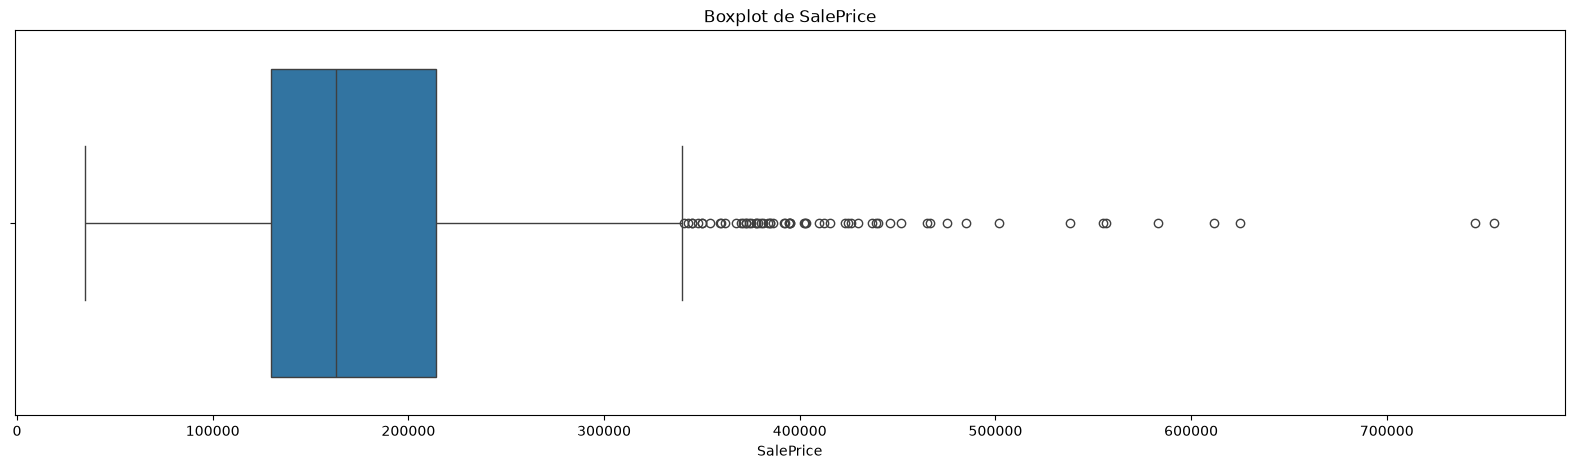

In [13]:
# Identificando Outliers na coluna SalePrice

plt.figure(figsize=(20, 5))
sns.boxplot(x = base_tratada['SalePrice'])
plt.title('Boxplot de SalePrice')
plt.show()

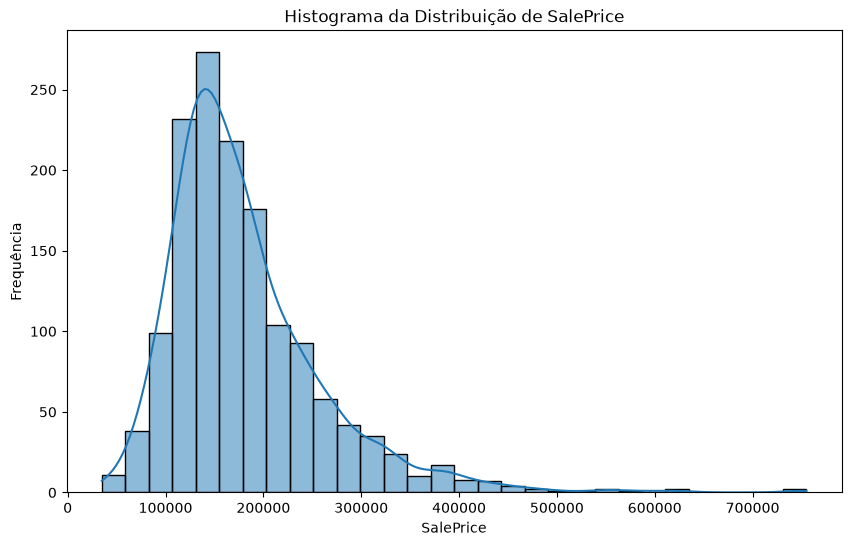

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(base_tratada['SalePrice'], kde=True, bins=30)
plt.title('Histograma da Distribuição de SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequência')
plt.show()

## Aplicando apenas Log1p

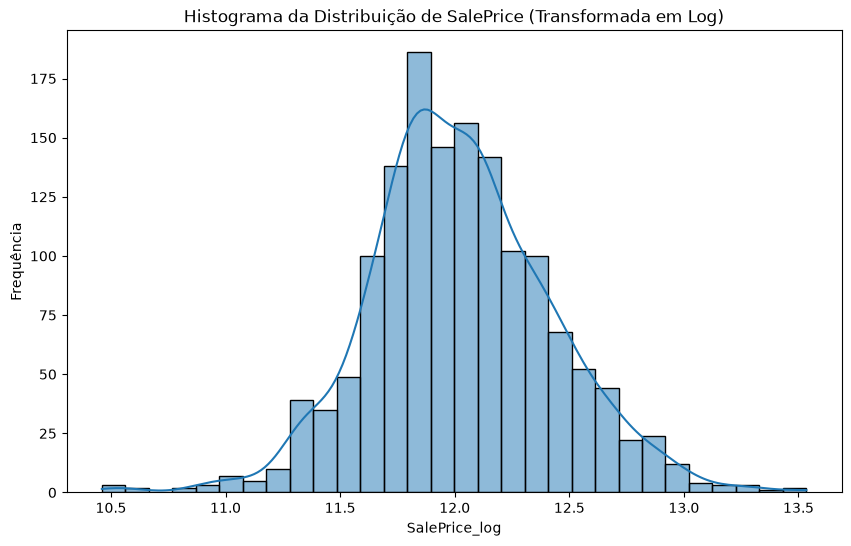

In [15]:
# Aplicar transformação logarítmica (log1p) na variável SalePrice
base_tratada_log = base_tratada
base_tratada_log['SalePrice_log'] = np.log1p(base_tratada_log['SalePrice'])

# Visualizar a nova distribuição de SalePrice_log
plt.figure(figsize=(10, 6))
sns.histplot(base_tratada_log['SalePrice_log'], kde=True, bins=30)
plt.title('Histograma da Distribuição de SalePrice (Transformada em Log)')
plt.xlabel('SalePrice_log')
plt.ylabel('Frequência')
plt.show()

## Aplicando IsolationForest + Log1p

In [16]:
# Removendo Outliers com IsolationForest

from sklearn.ensemble import IsolationForest

#Treinar o modelo

iso_forest = IsolationForest(random_state=42, contamination=0.05)
base_tratada['Outlier'] = iso_forest.fit_predict(base_tratada[['SalePrice']])
base_tratada_IF = base_tratada[base_tratada['Outlier'] != -1]

print('Base numerica após remover os Outliers: ', base_tratada_IF.shape[0])

Base numerica após remover os Outliers:  1387


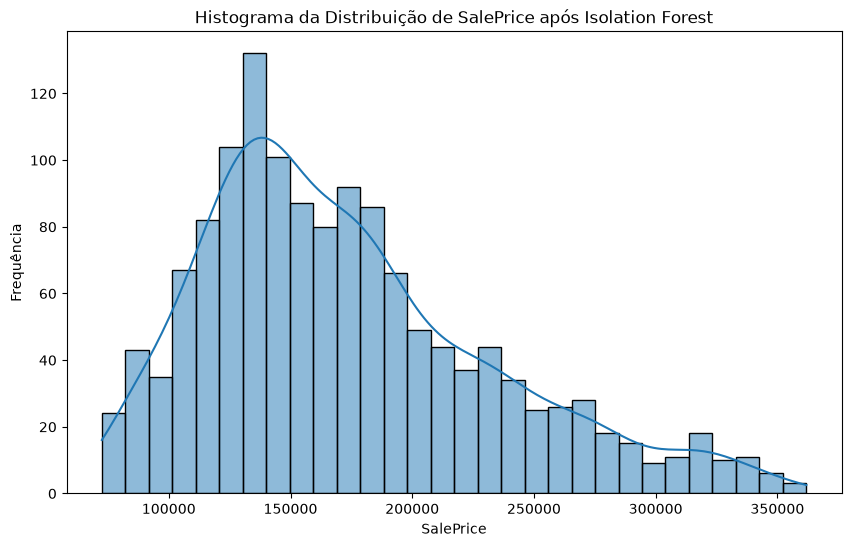

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(base_tratada_IF['SalePrice'], kde=True, bins=30)
plt.title('Histograma da Distribuição de SalePrice após Isolation Forest')
plt.xlabel('SalePrice')
plt.ylabel('Frequência')
plt.show()

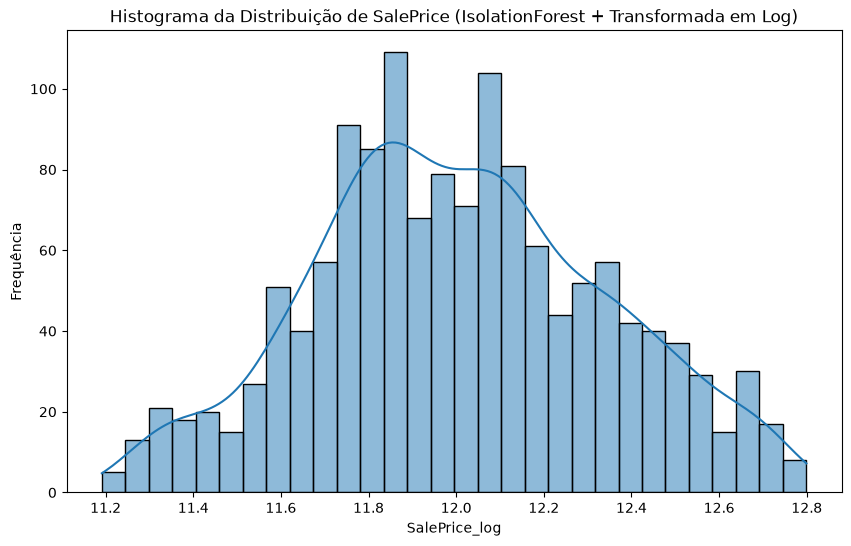

In [18]:
# Aplicar transformação logarítmica (log1p) na variável SalePrice
base_tratada_IF['SalePrice_log'] = np.log1p(base_tratada_IF['SalePrice'])

# Visualizar a nova distribuição de SalePrice_log
plt.figure(figsize=(10, 6))
sns.histplot(base_tratada_IF['SalePrice_log'], kde=True, bins=30)
plt.title('Histograma da Distribuição de SalePrice (IsolationForest + Transformada em Log)')
plt.xlabel('SalePrice_log')
plt.ylabel('Frequência')
plt.show()

## Aplicando IQR + Log1p

In [19]:
# 1. Cálculo do IQR na variável SalePrice_log
Q1 = base_tratada_log['SalePrice_log'].quantile(0.25)
Q3 = base_tratada_log['SalePrice_log'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

In [20]:
# 2. Filtrando a base pelo método do IQR
base_tratada_IQR = base_tratada_log[
    (base_tratada_log['SalePrice_log'] >= limite_inferior) & 
    (base_tratada_log['SalePrice_log'] <= limite_superior)
].copy()

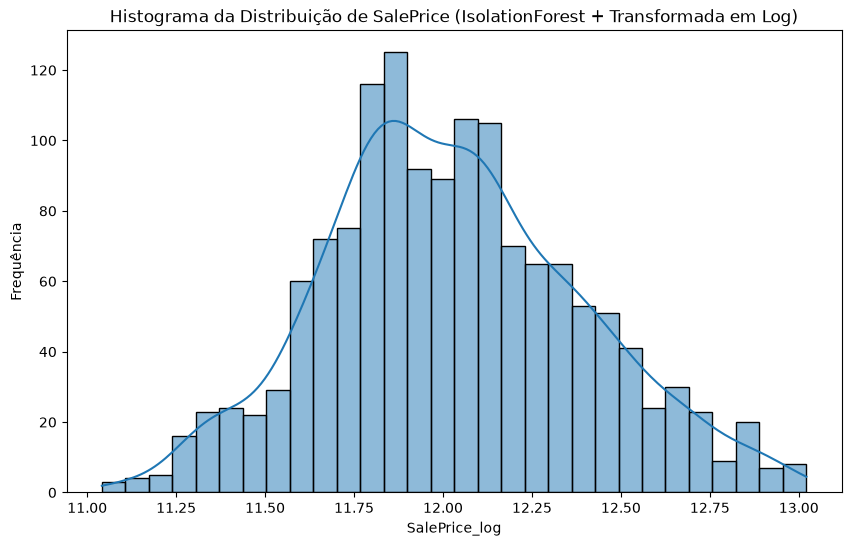

In [21]:
# Visualizar a nova distribuição de SalePrice_log + IQR
plt.figure(figsize=(10, 6))
sns.histplot(base_tratada_IQR['SalePrice_log'], kde=True, bins=30)
plt.title('Histograma da Distribuição de SalePrice (IsolationForest + Transformada em Log)')
plt.xlabel('SalePrice_log')
plt.ylabel('Frequência')
plt.show()

## Comparando as 3 tratativas

In [22]:
print(f"Tamanho original (Só Log): {len(base_tratada_log)}")
print(f"Tamanho após Isolation Forest: {len(base_tratada_IF)}")
print(f"Tamanho após IQR: {len(base_tratada_IQR)}")

Tamanho original (Só Log): 1460
Tamanho após Isolation Forest: 1387
Tamanho após IQR: 1432


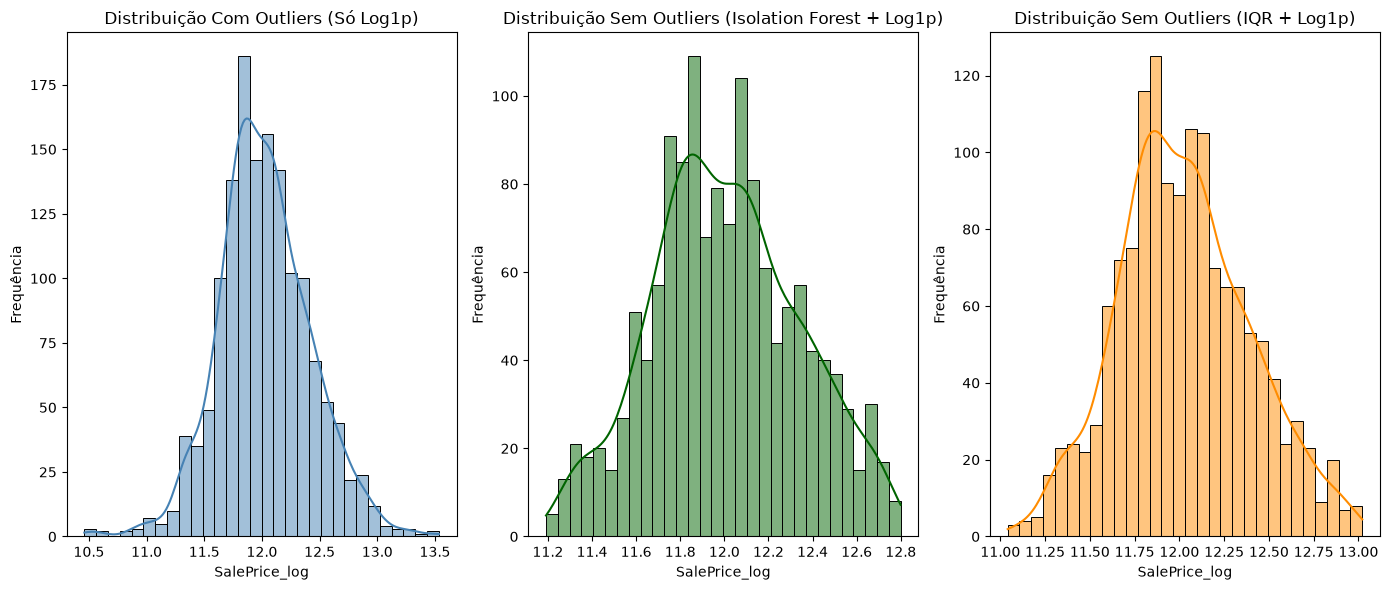

In [23]:
# Cria uma figura com 2 gráficos lado a lado (1 linha, 2 colunas)
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharey=False)

# Gráfico 1: Com Outliers (Log1p)
sns.histplot(base_tratada_log['SalePrice_log'], kde=True, bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição Com Outliers (Só Log1p)')
axes[0].set_xlabel('SalePrice_log')
axes[0].set_ylabel('Frequência')

# Gráfico 2: Sem Outliers (Isolation Forest + Log1p)
sns.histplot(base_tratada_IF['SalePrice_log'], kde=True, bins=30, ax=axes[1], color='darkgreen')
axes[1].set_title('Distribuição Sem Outliers (Isolation Forest + Log1p)')
axes[1].set_xlabel('SalePrice_log')
axes[1].set_ylabel('Frequência')

# Gráfico 3: Sem Outliers (IQR + Log1p)
sns.histplot(base_tratada_IQR['SalePrice_log'], kde=True, bins=30, ax=axes[2], color='darkorange')
axes[2].set_title('Distribuição Sem Outliers (IQR + Log1p)')
axes[2].set_xlabel('SalePrice_log')
axes[2].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

In [24]:

# Base tratada com Log puro
base_tratada_log.to_csv('../data/processed/train_log.csv', index=False)

# Base do Isolation Forest
base_tratada_IF.to_csv('../data/processed/train_if.csv', index=False)

# Base do IQR
base_tratada_IQR.to_csv('../data/processed/train_iqr.csv', index=False)